In [7]:
import pandas as pd
import numpy as np

In [9]:
courses=pd.read_csv("courses.csv")
matches=pd.read_csv("matches.csv")
nov=pd.read_csv("reg-month1.csv")
dec=pd.read_csv("reg-month2.csv")
students=pd.read_csv("students.csv")


In [11]:
import requests
from io import StringIO
file_id="1xzluAOVoDwpcFg0YiqF0EOUAh__SK2b4"
url=f"https://drive.google.com/uc?id={file_id}"
response=requests.get(url)
if response.status_code==200:
    csv_data=StringIO(response.text)
    delivery=pd.read_csv(csv_data)
else:
    print('failed to fetch the file')

In [12]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [49]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [50]:
nov

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [51]:
dec

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


<h3><font color='red'>pd.concat</font></h3>

In [15]:
''' there will be times where we want to vertically stack the two dataframe'''
pd.concat([nov,dec]) # we merged nov and december data.

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [17]:
pd.concat?

Signature:
pd.concat(
    objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]',
    *,
    axis: 'Axis' = 0,
    join: 'str' = 'outer',
    ignore_index: 'bool' = False,
    keys: 'Iterable[Hashable] | None' = None,
    levels=None,
    names: 'list[HashableT] | None' = None,
    verify_integrity: 'bool' = False,
    sort: 'bool' = False,
    copy: 'bool | None' = None,
) -> 'DataFrame | Series'
Docstring:
Concatenate pandas objects along a particular axis.

Allows optional set logic along the other axes.

Can also add a layer of hierarchical indexing on the concatenation axis,
which may be useful if the labels are the same (or overlapping) on
the passed axis number.

Parameters
----------
objs : a sequence or mapping of Series or DataFrame objects
    If a mapping is passed, the sorted keys will be used as the `keys`
    argument, unless it is passed, in which case the values will be
    selected (see below). Any None objects will be dropped silently unless
  

In [19]:
''' in the above merged dataframe the indexes are retained which can cause confusino in future'''
regs=pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


### What if we want to keep originl index and still create differentiation.
#### This can be done using a parameter of pd.concat i.e keys 

- Keys is a list in which we can give name, one for each dataframe it means provide name1 
for dataframe1 and name2 for another dataframe2
- In result you will get a dataframe called <font color='green'>Multiindex</font>dataframe.

In [22]:
''' what if we want to stack it horizontally'''
multi=pd.concat([nov,dec],keys=['November','December'])
# keys is a list in which we can give name one for each dataframe 
#here it means provide 'november' name to nov list elements and 'december' to dec list elements.
# This is multiindex dataframe: where we have index more than one.

In [24]:
multi

student_id  course_id
November 0           23          1
         1           15          5
         2           18          6
         3           23          4
         4           16          9
         5           18          1
         6            1          1
         7            7          8
         8           22          3
         9           15          1
         10          19          4
         11           1          6
         12           7         10
         13          11          7
         14          13          3
         15          24          4
         16          21          1
         17          16          5
         18          23          3
         19          17          7
         20          23          6
         21          25          1
         22          19          2
         23          25         10
         24           3          3
December 0            3          5
         1           16          7
         2           12         10
         3           12          1
         4           14          9
         5            7          7
         6            7          2
         7           16          3
         8           17         10
         9           11          8
         10          14          6
         11          12          5
         12          12          7
         13          18          8
         14           1         10
         15           1          9
         16           2          5
         17           7          6
         18          22          5
         19          22          6
         20          23          9
         21          23          5
         22          14          4
         23          14          1
         24          11         10
         25          42          9
         26          50          8
         27          38          1

In [26]:
multi.loc['November']

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [28]:
'''access a soecific dataframe '''
multi.loc['December']

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [30]:
''' acces the specific element from a dataframe'''
multi.loc[('November',0)] 

student_id    23
course_id      1
Name: (November, 0), dtype: int64

In [32]:
multi.loc[('December'),4]

student_id    14
course_id      9
Name: (December, 4), dtype: int64

In [34]:
''' how to stack data horizontally'''
pd.concat([nov,dec],axis=1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


In [36]:
pd.concat([nov,dec],axis=1).shape
# here number of columns increase and the rows will be equal to the number of rows in bigger data

(28, 4)

In [38]:
''' concat with unequal number of columns'''
df1=pd.DataFrame([[1,2,4,5],
                 [2,3,4,5],
                 [1,5,7,8]],columns=['A','B','C','D'])
df2=pd.DataFrame([[2,3,4,5,6],
                 [5,6,8,9,8],
                 [2,3,4,6,7]])

In [40]:
pd.concat([df1,df2],keys=['df1','df2'])

A    B    C    D    0    1    2    3    4
df1 0  1.0  2.0  4.0  5.0  NaN  NaN  NaN  NaN  NaN
    1  2.0  3.0  4.0  5.0  NaN  NaN  NaN  NaN  NaN
    2  1.0  5.0  7.0  8.0  NaN  NaN  NaN  NaN  NaN
df2 0  NaN  NaN  NaN  NaN  2.0  3.0  4.0  5.0  6.0
    1  NaN  NaN  NaN  NaN  5.0  6.0  8.0  9.0  8.0
    2  NaN  NaN  NaN  NaN  2.0  3.0  4.0  6.0  7.0

In [44]:
pd.concat([df1,df2],keys=["df1",'df2'],axis=1)

df1          df2            
    A  B  C  D   0  1  2  3  4
0   1  2  4  5   2  3  4  5  6
1   2  3  4  5   5  6  8  9  8
2   1  5  7  8   2  3  4  6  7

In [46]:
pd.concat([df1,df2],keys=['df1','df2'],join='inner')

Empty DataFrame
Columns: []
Index: [(df1, 0), (df1, 1), (df1, 2), (df2, 0), (df2, 1), (df2, 2)]

## Merge

- It is similar to joins in sql, we can join dataframes on the basis of one comman column.

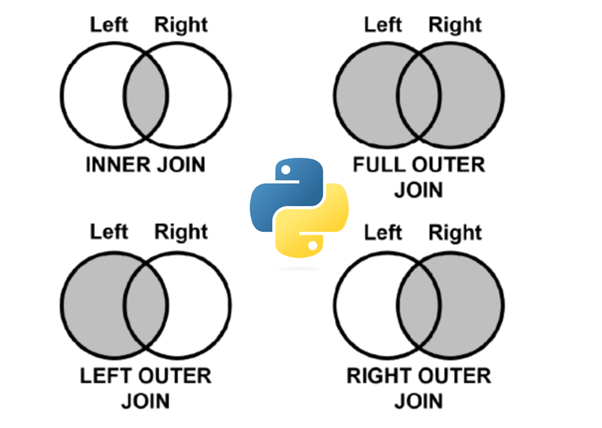

## Inner Joins

- only common elements are visible

In [158]:
students.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


## Left join

- we print common elements along with  elements present in left table but not present in right table.

In [161]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [163]:
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [165]:
courses.merge(regs,how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


## Right join

- Only the common elements and the elements present only on right table are present.

In [174]:
temp=pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Rahul','Prashant','Ankit'],
    'partner':[28,26,27]})
temp

,student_id,name,partner
0,26,Rahul,28
1,27,Prashant,26
2,28,Ankit,27


In [195]:
students=pd.concat([students,temp],ignore_index=True)


In [197]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [199]:
students.merge(regs,how='right',on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [201]:
regs.merge(students,how='right',on='student_id')

,student_id,course_id,name,partner
0,1,1.0,Kailash Harjo,23
1,1,6.0,Kailash Harjo,23
2,1,10.0,Kailash Harjo,23
3,1,9.0,Kailash Harjo,23
4,2,5.0,Esha Butala,1
5,3,3.0,Parveen Bhalla,3
6,3,5.0,Parveen Bhalla,3
7,4,NaN,Marlo Dugal,14
8,5,NaN,Kusum Bahri,6
9,6,NaN,Lakshmi Contractor,10


<h3>Outer Join</h3>

- All the elements including common and uncommon.


In [220]:
students.merge(regs,how='outer',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,1,Kailash Harjo,23.0,6.0
2,1,Kailash Harjo,23.0,10.0
3,1,Kailash Harjo,23.0,9.0
4,2,Esha Butala,1.0,5.0
...,...,...,...,...
58,27,Prashant,26.0,NaN
59,28,Ankit,27.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0


In [222]:
students.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [248]:
''' find total revenue generateded'''
revenue=courses.merge(regs,how='inner',on='course_id')
revenue

,course_id,course_name,price,student_id
0,1,python,2499,23
1,1,python,2499,18
2,1,python,2499,1
3,1,python,2499,15
4,1,python,2499,21
5,1,python,2499,25
6,1,python,2499,12
7,1,python,2499,14
8,1,python,2499,38
9,2,sql,3499,19


In [267]:
revenue.groupby('course_name')['price'].sum()

course_name
data analysis       24995
machine learning    39996
ms sxcel             7995
pandas               4396
plotly               3495
power bi            11394
pyspark             14994
python              22491
sql                  6998
tableau             17493
Name: price, dtype: int64

In [252]:
revenue['price'].sum()

154247

In [290]:
''' alerternate method'''
courses.merge(regs,how='inner',on='course_id')['price'].sum()

154247

In [288]:
''' find month by month revenue'''
courses.merge(nov,how='inner',on='course_id')['price'].sum()

89175

In [292]:
courses.merge(dec,how='inner',on='course_id')['price'].sum()

65072

In [298]:
r=pd.concat([nov,dec],keys=['november','december']).reset_index()

In [320]:
r

,level_0,level_1,student_id,course_id
0,november,0,23,1
1,november,1,15,5
2,november,2,18,6
3,november,3,23,4
4,november,4,16,9
5,november,5,18,1
6,november,6,1,1
7,november,7,7,8
8,november,8,22,3
9,november,9,15,1


In [310]:
r.merge(courses,on='course_id').groupby('level_0')['price'].sum()

level_0
december    65072
november    89175
Name: price, dtype: int64

In [333]:
'''Print a registrtion table 
cols->name->course->price'''
regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


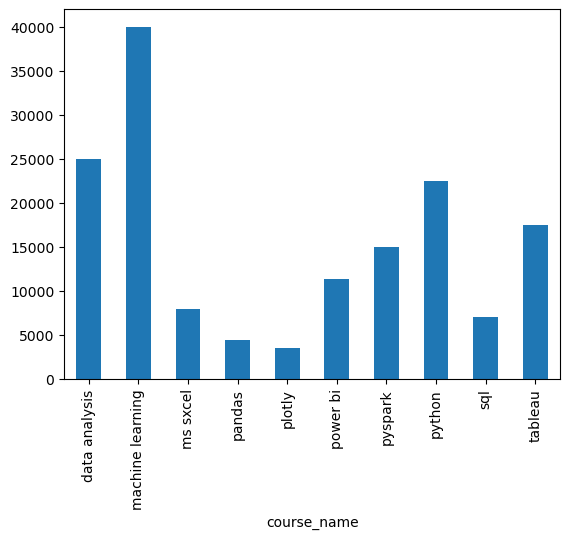

In [48]:
''' plot a bar chart for revenue/course'''
regs.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar');

In [361]:
''' find students who enrolled in both the months'''
common_id=np.intersect1d(nov['student_id'],dec['student_id'])

In [369]:
students[students['student_id'].isin(common_id)]#they are loyal students

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [407]:
course_id=np.setdiff1d(courses['course_id'],regs['course_id'])

In [411]:
courses[courses['course_id'].isin(course_id)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [417]:
''' find the students who did not enroll in any course'''
student=np.setdiff1d(students['student_id'],regs['student_id'])

In [427]:
students[students['student_id'].isin(student)]

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11
25,26,Rahul,28
26,27,Prashant,26
27,28,Ankit,27


In [431]:
(10/28)*100

35.714285714285715

## Self join

- a table is joined within itself

In [433]:
''' print student name-> partner name for all enrolled students'''
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [463]:
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [475]:
students.merge(students,how='inner', left_on='partner',right_on='student_id')

,student_id_x,name_x,partner_x,student_id_y,name_y,partner_y
0,1,Kailash Harjo,23,23,Chhavi Lachman,18
1,2,Esha Butala,1,1,Kailash Harjo,23
2,3,Parveen Bhalla,3,3,Parveen Bhalla,3
3,4,Marlo Dugal,14,14,Pranab Natarajan,22
4,5,Kusum Bahri,6,6,Lakshmi Contractor,10
5,6,Lakshmi Contractor,10,10,Aayushman Sant,8
6,7,Tarun Thaker,9,9,Nitika Chatterjee,4
7,8,Radheshyam Dey,5,5,Kusum Bahri,6
8,9,Nitika Chatterjee,4,4,Marlo Dugal,14
9,10,Aayushman Sant,8,8,Radheshyam Dey,5


In [497]:
''' find top 3 students who did most number enrollments'''
regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].value_counts().sort_values(ascending=False).head(3)

student_id  name          
23          Chhavi Lachman    6
7           Tarun Thaker      5
1           Kailash Harjo     4
Name: count, dtype: int64

In [509]:
''' find top 3 students who spent most amount of money on courses'''
regs.merge(students, on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

In [513]:
''' alternate syntax for merge'''
students.merge(regs)

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [515]:
pd.merge(students,regs,on='student_id',how='inner')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [525]:
''' ipl dataset'''
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [527]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [539]:
temp_df=delivery.merge(matches,left_on='match_id',right_on='id')

In [545]:
six_df=temp_df[temp_df['batsman_runs']==6]

In [559]:
#stadium->sixes
num_six=six_df.groupby('venue')['venue'].count()

In [561]:
num_matches=matches['venue'].value_counts()

In [565]:
(num_six/num_matches).sort_values(ascending=False).head(3)

venue
Holkar Cricket Stadium     17.600000
M Chinnaswamy Stadium      13.227273
Sharjah Cricket Stadium    12.666667
dtype: float64

In [567]:
''' find orange cap holder of all seasons ( a guy with most number of runs of a season)'''
matches

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [599]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
